### 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr



np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)


### 2. Load the dataset

In [8]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


#### 3. Data Quality checks

##### 3.1 Basic dataset overview

In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=[np.object_, 'category']).columns.tolist()

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: ['age', 'bmi', 'children', 'charges']
Categorical columns: ['sex', 'smoker', 'region']


/var/folders/85/_7ym_kd52wl9lwnxjnhk2mxc0000gn/T/ipykernel_21733/1573682697.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=[np.object_, 'category']).columns.tolist()


In [17]:
print("Shape of the dataset:", df.shape)
print("Data types of the columns:\n", df.columns.to_list())

print("-" * 50)
print("data types of the columns:\n", df.dtypes)
print("-" * 50)
print("Unique values in each column:\n", df.nunique())
print("-" * 50)
print("Descriptive statistics of numerical columns:\n", df.describe())
print("-" * 50)
print("Info:\n", df.info())



Shape of the dataset: (1338, 7)
Data types of the columns:
 ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
--------------------------------------------------
data types of the columns:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object
--------------------------------------------------
Unique values in each column:
 age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64
--------------------------------------------------
Descriptive statistics of numerical columns:
            age      bmi  children   charges
count 1338.000 1338.000  1338.000  1338.000
mean    39.207   30.663     1.095 13270.422
std     14.050    6.098     1.205 12110.011
min     18.000   15.960     0.000  1121.874
25%     27.000   26.296     0.000  4740.287
50%     39.000   30.400     1.000  9382.033
75%     51.000   34.694

In [20]:
#### 3.2 Missing Values - Analysis
missing_values = df.isna().sum()
missing_values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
missing_count = missing_values.sort_values(ascending=False)
missing_percent = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing_count, 'Missing Percent': missing_percent})
print(missing_summary)

          Missing Count  Missing Percent
age                   0            0.000
sex                   0            0.000
bmi                   0            0.000
children              0            0.000
smoker                0            0.000
region                0            0.000
charges               0            0.000


##### note: No missing values in the dataset. Still need to verify encoded missing values.
###### example: -999, 999, unknown

In [22]:
for col in df.columns:
    print(df[col].value_counts())
    print("-" * 50)

age
18    69
19    68
46    29
52    29
48    29
20    29
45    29
47    29
51    29
50    29
28    28
25    28
23    28
27    28
22    28
26    28
24    28
21    28
53    28
54    28
49    28
31    27
30    27
41    27
40    27
43    27
44    27
29    27
42    27
33    26
32    26
56    26
34    26
55    26
57    26
37    25
59    25
35    25
38    25
36    25
58    25
39    25
60    23
62    23
63    23
61    23
64    22
Name: count, dtype: int64
--------------------------------------------------
sex
male      676
female    662
Name: count, dtype: int64
--------------------------------------------------
bmi
32.300    13
28.310     9
28.880     8
34.100     8
30.800     8
          ..
53.130     1
39.710     1
32.870     1
44.700     1
30.970     1
Name: count, Length: 548, dtype: int64
--------------------------------------------------
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
--------------------------------------------------
smoker
no 

#### 3.3 Duplicate

In [23]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print(f"Number of duplicate rows: {num_duplicates}")
print("Duplicate rows:\n", df[duplicate_mask])


Number of duplicate rows: 1
Duplicate rows:
      age   sex    bmi  children smoker     region  charges
581   19  male 30.590         0     no  northwest 1639.563


In [24]:
# remove duplicate 
df_no_duplicates = df.drop_duplicates()
print(f"Shape of the dataset after removing duplicates: {df_no_duplicates.shape}")

Shape of the dataset after removing duplicates: (1337, 7)


In [25]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

#### 3.5 Constant and quasi-constant


In [ ]:
n_rows = len(df)
nunique = df.nunique()

constant_cols = nunique[nunique == 1].index.tolist()
print(f"Constant columns: {constant_cols}")

# Qualsi constant: top value more than 95 percent
qual_constant_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.95 and col not in constant_cols:
        qual_constant_cols.append(col)

print(f"Quasi-constant columns: {qual_constant_cols}")



Constant columns: []
Quasi-constant columns: []


########## No constant or quasi-constant columns found in the dataset.

#### 3.6 ID like columns

In [28]:
id_like_cols = []

for col in df.columns:
    if df[col].nunique(dropna=False) == n_rows:
        id_like_cols.append(col)

print(f"ID-like columns: {id_like_cols}")


ID-like columns: []


In [30]:
#### 3.7 High zero columns (numeric)

zero_share = {}
for col in num_cols:
    zero_share[col] = (df[col] == 0).mean()

zero_share_series = pd.Series(zero_share).sort_values(ascending=False)   
zero_share_series


high_zero_threshold = 0.8
high_zero_cols = zero_share_series[zero_share_series >= high_zero_threshold]
print("Numeric columns with many zeros:")
high_zero_cols


Numeric columns with many zeros:


Series([], dtype: float64)

### 4 Univariate Analysis

##### Numerical Feature Analysis
#### Descriptive Statistics - Summary

In [32]:
print("Summary statistics of the dataset:\n", df[num_cols].describe())

Summary statistics of the dataset:
            age      bmi  children   charges
count 1338.000 1338.000  1338.000  1338.000
mean    39.207   30.663     1.095 13270.422
std     14.050    6.098     1.205 12110.011
min     18.000   15.960     0.000  1121.874
25%     27.000   26.296     0.000  4740.287
50%     39.000   30.400     1.000  9382.033
75%     51.000   34.694     2.000 16639.913
max     64.000   53.130     5.000 63770.428


#### 4.1 Central Tendency and Dispersion

In [33]:
print("Mean of each numeric column:\n", df[num_cols].mean())
print("Median of each numeric column:\n", df[num_cols].median())
print("Mode of each numeric column:\n", df[num_cols].mode().iloc[0])

Mean of each numeric column:
 age           39.207
bmi           30.663
children       1.095
charges    13270.422
dtype: float64
Median of each numeric column:
 age          39.000
bmi          30.400
children      1.000
charges    9382.033
dtype: float64
Mode of each numeric column:
 age          18.000
bmi          32.300
children      0.000
charges    1639.563
Name: 0, dtype: float64


#### 4.3 Distribution

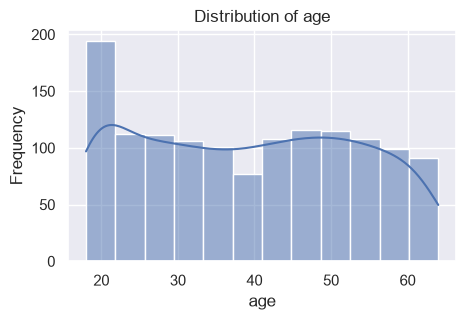

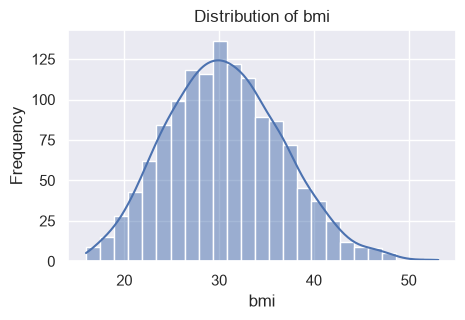

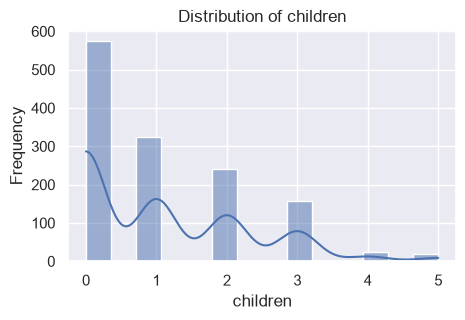

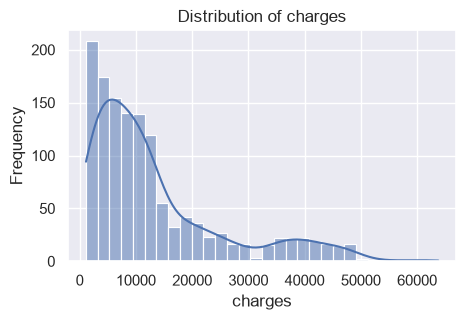

In [38]:
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True, )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [39]:
print("\nSkewness")
print(df[num_cols].skew())  ### skewness measures the asymmetry of the distribution of values in a dataset. A skewness value greater than 0 indicates a right-skewed distribution, while a value less than 0 indicates a left-skewed distribution. A value close to 0 suggests a symmetric distribution.
print("\nKurtosis")
print(df[num_cols].kurtosis()) 


Skewness
age        0.056
bmi        0.284
children   0.938
charges    1.516
dtype: float64

Kurtosis
age        -1.245
bmi        -0.051
children    0.202
charges     1.606
dtype: float64


In [40]:
for col in cat_cols:
    print(f"\nFrequency Table for {col}:")
    print(df[col].value_counts())
    print(f"\nProportions for {col}:")
    print(df[col].value_counts(normalize=True))


Frequency Table for sex:
sex
male      676
female    662
Name: count, dtype: int64

Proportions for sex:
sex
male     0.505
female   0.495
Name: proportion, dtype: float64

Frequency Table for smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

Proportions for smoker:
smoker
no    0.795
yes   0.205
Name: proportion, dtype: float64

Frequency Table for region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Proportions for region:
region
southeast   0.272
southwest   0.243
northwest   0.243
northeast   0.242
Name: proportion, dtype: float64


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

#### 5. Bivariate Analysis

##### Numerical vs Numerical Features

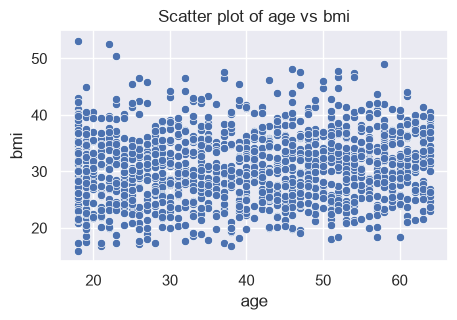

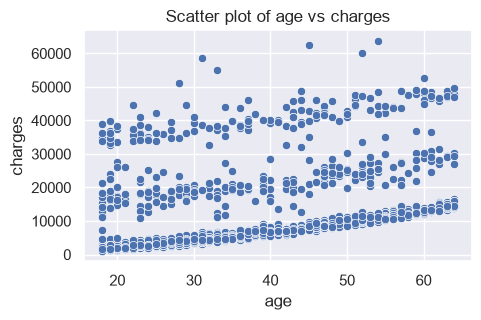

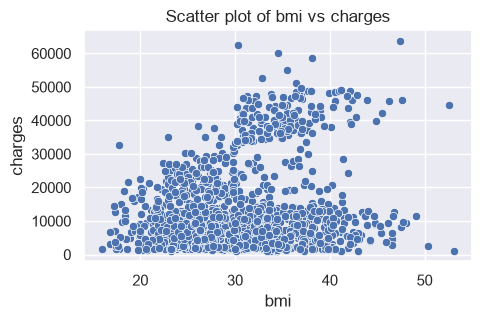

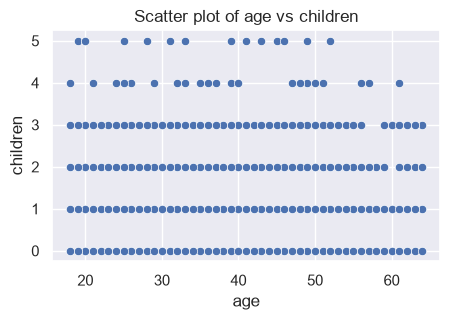

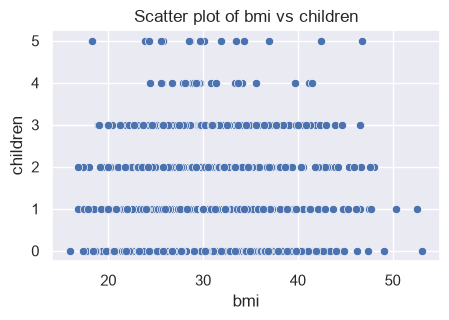

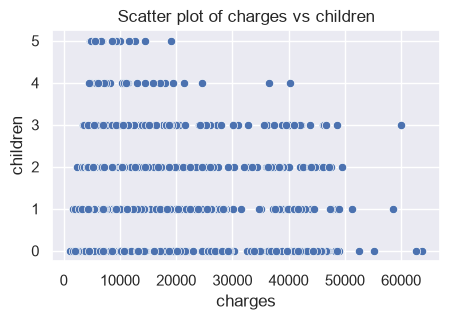

In [44]:
num_pairs = [("age", "bmi"), ("age", "charges"), ("bmi", "charges"), ("age", "children"), ("bmi", "children"), ("charges", "children")]

for x,y in num_pairs:
    plt.figure(figsize=(5, 3))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f'Scatter plot of {x} vs {y}')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

#### 6. Correlation Matrix

In [45]:
df[num_cols].corr()

,age,bmi,children,charges
age,1.000,0.109,0.042,0.299
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.068
charges,0.299,0.198,0.068,1.000


In [47]:
print("Pearson correlation with fare:")

for col in num_cols:
    if col != "fare":
        r,p = pearsonr(df[col], df["age"])
        print(f"{col} vs fare: r={r:.2f}, p={p:.4f}")

Pearson correlation with fare:
age vs fare: r=1.00, p=0.0000
bmi vs fare: r=0.11, p=0.0001
children vs fare: r=0.04, p=0.1205
charges vs fare: r=0.30, p=0.0000


#### 7. Numerical and Categorical Features

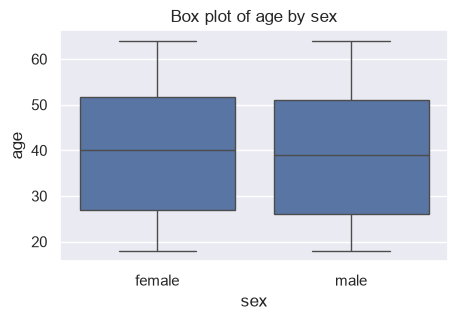

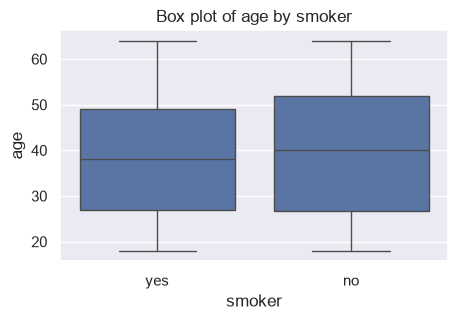

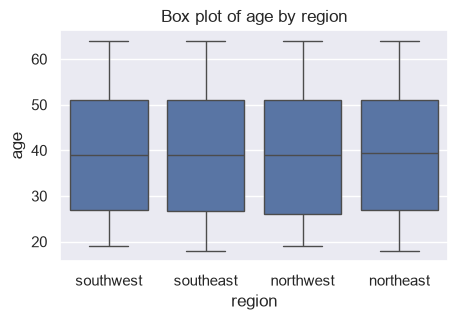

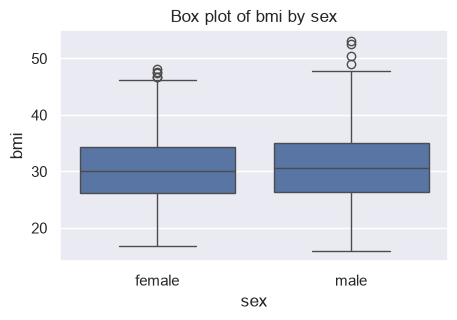

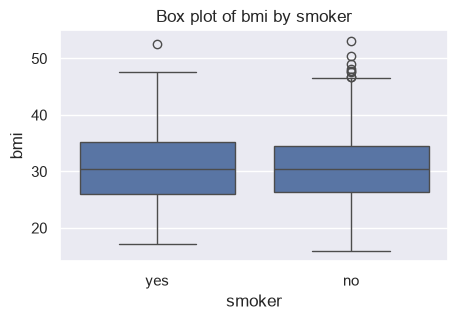

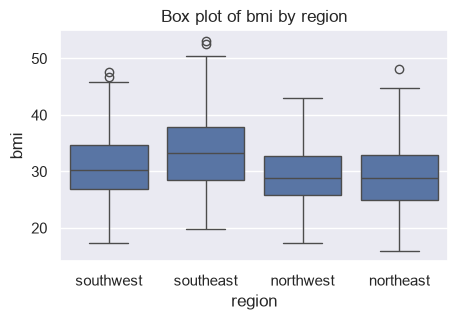

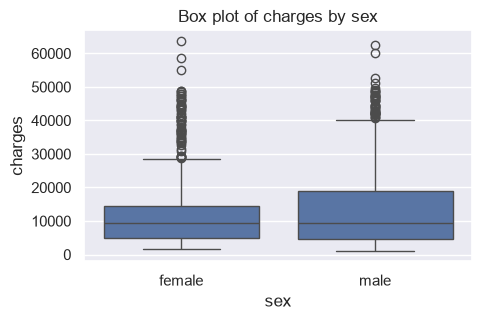

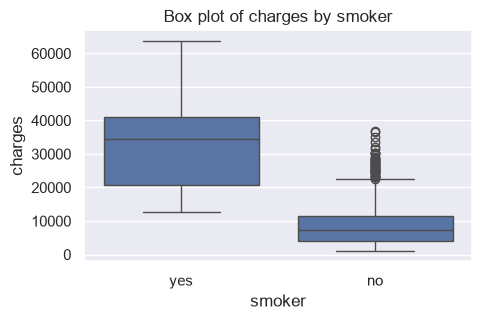

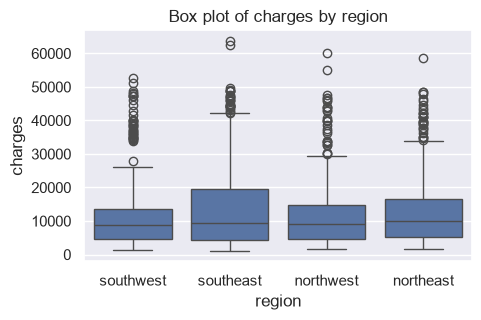

In [48]:
num_for_box = ["age", "bmi", "charges"]
cat_for_box = ["sex", "smoker", "region",]

for num in num_for_box:
    for cat in cat_for_box:
        plt.figure(figsize=(5, 3))
        sns.boxplot(x=cat, y=num, data=df)
        plt.title(f'Box plot of {num} by {cat}')
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

In [49]:
df["charges"]

0      16884.924
1       1725.552
2       4449.462
3      21984.471
4       3866.855
          ...   
1333   10600.548
1334    2205.981
1335    1629.833
1336    2007.945
1337   29141.360
Name: charges, Length: 1338, dtype: float64

In [ ]:
df["charges_copy"] = df["charges"].copy()